# Zero shot object detection

In [1]:
import torch
import requests
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

In [2]:
model_id = "google/owlv2-base-patch16-ensemble"

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
processor = AutoProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

In [5]:
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/418 [00:00<?, ?it/s]

In [21]:
queries = [["a shoe", "towel", "bottle", "watch"]]

In [29]:
def check_gym_bag(img_path, threshold):
  image = Image.open(img_path)
  image = image.resize((320, 240))

  image_copy = image.copy()
  #for finding the missing contents in the bag
  inputs = processor(images=image, text=queries, return_tensors="pt").to(device)
  sizes = [image.size[::-1]]
  with torch.no_grad():
    outputs = model(**inputs)

  results = processor.post_process_grounded_object_detection(outputs, #output from the model
                                                           threshold=threshold, #drops anything with confidence less than 0.3
                                                           target_sizes=sizes,
                                                           text_labels=queries)
  contents = list(set(results[0]["text_labels"]))
  not_in_bag = [query for query in queries[0] if query not in contents]
  not_in_bag = ", ".join([str(x) for x in not_in_bag])

  #creating object detection image
  draw = ImageDraw.Draw(image_copy)
  font = ImageFont.load_default(size=20)

  for box, label in zip(results[0]["boxes"],
                             results[0]["text_labels"]):
    x_min, y_min, x_max, y_max = box.tolist()
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)
    draw.text((x_min, y_min), f"{label}", fill="white", font=font)

  return not_in_bag, image_copy



In [31]:
image_path = "/content/test.jpg"
missing, im = check_gym_bag(image_path, 0.3)
print(f"The following items are missing in your gym bad: {missing}")

The following items are missing in your gym bad: watch


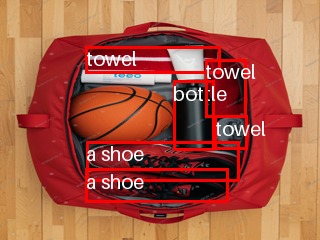

In [32]:
im

In [33]:
import gradio as gr

In [36]:
demo = gr.Interface(
    fn=check_gym_bag,
    inputs=[gr.Image(type="filepath"), gr.Slider(-1, 2, value=0.3, label="threshold")],
    outputs = ["text", gr.Image()]
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bc60e01a527361197c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.


KeyboardInterrupt: 